In [1]:
from pathlib import Path
import os

IMAGES_PATH = Path("../resources/cloud-images/CCSN_v2")

def index_labeled_images(images_path=IMAGES_PATH):
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }

    return labeled_images

In [2]:
labeled_images = index_labeled_images()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def extract_labels(labeled_images):
    labels = []
    paths = []
    for (i, image_name) in enumerate(labeled_images):
        path = labeled_images[image_name]['path']
        paths.append(path)
        label = labeled_images[image_name]['label']
        labels.append(label)

    return paths, np.array(labels)

In [4]:
paths, labels = extract_labels(labeled_images)

In [5]:
print(labels)

['Ac' 'Ac' 'Ac' ... 'St' 'St' 'St']


In [6]:
print(paths)

['../resources/cloud-images/CCSN_v2/Ac/Ac-N001.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N002.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N003.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N004.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N005.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N006.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N007.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N008.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N009.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N010.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N011.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N012.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N013.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N014.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N015.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N016.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N017.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N018.jpg', '../resources/cloud-images/CCSN_v2/Ac/Ac-N019.jpg', '../resourc

In [7]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [8]:
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
from functools import partial

In [9]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [10]:
list(torchvision.models.get_model_weights("vit_b_16"))

[ViT_B_16_Weights.IMAGENET1K_V1,
 ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1,
 ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1]

In [11]:
weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
model = torchvision.models.vit_b_16(weights=weights).to(device)

In [12]:
import torchvision.transforms.v2 as T

# transforms = weights.transforms()
transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [13]:
print(transforms)

Compose(
      RandomHorizontalFlip(p=0.5)
      RandomRotation(degrees=[-30.0, 30.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=InterpolationMode.BILINEAR, antialias=True)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


In [14]:
from sklearn.preprocessing import LabelEncoder

def encode_labels(labels):
    ordinal_encoder = LabelEncoder()
    encoded_labels = ordinal_encoder.fit_transform(labels)
    class_names = ordinal_encoder.classes_
    return encoded_labels, class_names


In [15]:
encoded_labels, class_names = encode_labels(labels)

In [16]:
print(class_names)

['Ac' 'As' 'Cb' 'Cc' 'Ci' 'Cs' 'Ct' 'Cu' 'Ns' 'Sc' 'St']


In [17]:
print(encoded_labels)

[ 0  0  0 ... 10 10 10]


In [18]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
import numpy as np

class MyImages(Dataset):
    def __init__(self, paths, encoded_labels, split="train", test_size=0.2, val_size=0.1, random_state=42, transform=None,
                 split_indices=None):

        if split not in {None, "train", "val", "test"}:
            raise ValueError(f"split must be one of {{'None','train','val','test'}}, got {split!r}")

        self.transform = transform

        paths = np.array(list(paths))
        encoded_labels = np.array(list(encoded_labels))

        n = len(paths)
        if n != len(encoded_labels):
            raise ValueError(f"paths and encoded_labels must have same length, got {n} and {len(labels)}")

        if split_indices is None:
            sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
            trainval_idx, test_idx = next(sss1.split(paths, encoded_labels))

            trainval_fraction = 1.0 - test_size
            val_within_trainval = val_size / trainval_fraction

            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_within_trainval, random_state=random_state)

            trainval_paths = paths[trainval_idx]
            trainval_labels = encoded_labels[trainval_idx]

            train_rel_idx, val_rel_idx = next(sss2.split(trainval_paths, trainval_labels))
            train_idx = trainval_idx[train_rel_idx]
            val_idx = trainval_idx[val_rel_idx]

            split_indices = {"train": train_idx, "val": val_idx, "test": test_idx}

        idx = split_indices[split]

        self.paths = paths[idx].tolist()
        self.encoded_labels = encoded_labels[idx].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


In [19]:
from functools import partial

DefaultCloudImages = partial(
    MyImages,
    paths=paths,
    encoded_labels=encoded_labels,
    transform=transforms,
    test_size=0.2,
    val_size=0.1,
    random_state=42
)

In [20]:
train_set = DefaultCloudImages(split="train")
valid_set = DefaultCloudImages(split="val")
test_set = DefaultCloudImages(split="test")

In [21]:
train_set[0]

(Image([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., 

In [22]:
len(train_set)
len(valid_set)
len(test_set)

509

In [23]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])

# create a dataset instance for the train split (use MyImages to request a split)
clouds_to_display = DefaultCloudImages(split="train", transform=transforms)


In [24]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.2565582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.367669].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8556867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.78597].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..1.66

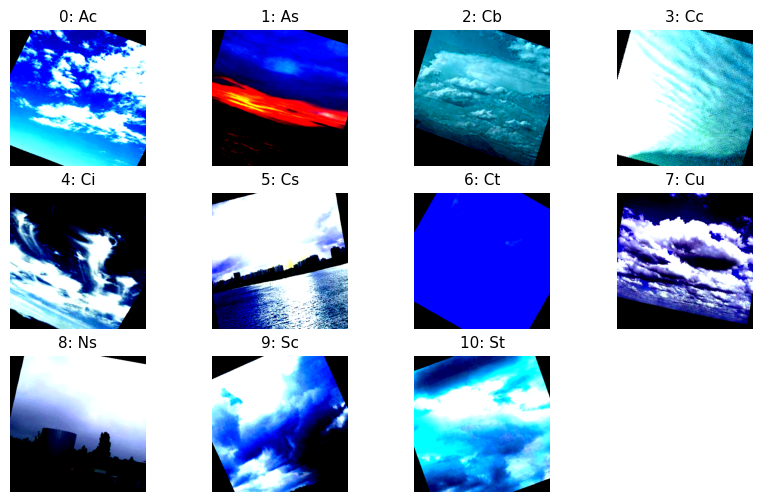

In [25]:
sample_clouds = sorted({y: img for img, y in clouds_to_display}.items())[:11]

plt.figure(figsize=(10, 6))
for class_id, image in sample_clouds:
    if class_id == 11: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [27]:
[name for name, child in model.named_children()]

['conv_proj', 'encoder', 'heads']

In [32]:
model.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [31]:
model.encoder

Encoder(
  (dropout): Dropout(p=0.0, inplace=False)
  (layers): Sequential(
    (encoder_layer_0): EncoderBlock(
      (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLPBlock(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=3072, out_features=768, bias=True)
        (4): Dropout(p=0.0, inplace=False)
      )
    )
    (encoder_layer_1): EncoderBlock(
      (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
    

In [34]:
model.conv_proj

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

In [35]:
n_classes = 11
model.heads[0] = nn.Linear(768, n_classes).to(device)

In [36]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

In [38]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [39]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=11).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 2.0059, train metric: 0.3142, valid metric: 0.3961
Epoch 2/5, train loss: 1.6012, train metric: 0.4452, valid metric: 0.4471
Epoch 3/5, train loss: 1.4672, train metric: 0.4896, valid metric: 0.4510
Epoch 4/5, train loss: 1.4182, train metric: 0.5160, valid metric: 0.4745
Epoch 5/5, train loss: 1.3721, train metric: 0.5363, valid metric: 0.4235


In [40]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 1.3027, train metric: 0.5576, valid metric: 0.4627
Epoch 2/5, train loss: 1.2753, train metric: 0.5711, valid metric: 0.4941
Epoch 3/5, train loss: 1.2402, train metric: 0.5745, valid metric: 0.4706
Epoch 4/5, train loss: 1.2204, train metric: 0.5823, valid metric: 0.4745
Epoch 5/5, train loss: 1.2077, train metric: 0.5807, valid metric: 0.4549


In [41]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 1.1915, train metric: 0.5711, valid metric: 0.4863
Epoch 2/5, train loss: 1.1531, train metric: 0.5998, valid metric: 0.5059
Epoch 3/5, train loss: 1.1435, train metric: 0.6020, valid metric: 0.4863
Epoch 4/5, train loss: 1.1489, train metric: 0.6076, valid metric: 0.4627
Epoch 5/5, train loss: 1.1215, train metric: 0.6110, valid metric: 0.4902


In [42]:
for param in model.encoder.layers[-1].parameters():
    param.requires_grad = True

evaluate_tm(model, test_loader, accuracy)

tensor(0.4912, device='mps:0')

In [43]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 4.8497, train metric: 0.1445, valid metric: 0.1922
Epoch 2/5, train loss: 2.0940, train metric: 0.2631, valid metric: 0.2824
Epoch 3/5, train loss: 1.8544, train metric: 0.3401, valid metric: 0.3216
Epoch 4/5, train loss: 1.6781, train metric: 0.3901, valid metric: 0.4157
Epoch 5/5, train loss: 1.6254, train metric: 0.4160, valid metric: 0.3333


In [44]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 1.6301, train metric: 0.4227, valid metric: 0.4275
Epoch 2/5, train loss: 1.4799, train metric: 0.4654, valid metric: 0.4196
Epoch 3/5, train loss: 1.4137, train metric: 0.4902, valid metric: 0.4353
Epoch 4/5, train loss: 1.4218, train metric: 0.5003, valid metric: 0.4549
Epoch 5/5, train loss: 1.3570, train metric: 0.5059, valid metric: 0.4392


In [45]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 1.3980, train metric: 0.5087, valid metric: 0.4471
Epoch 2/5, train loss: 1.3462, train metric: 0.5188, valid metric: 0.4706
Epoch 3/5, train loss: 1.3646, train metric: 0.5200, valid metric: 0.4353
Epoch 4/5, train loss: 1.3298, train metric: 0.5250, valid metric: 0.4510
Epoch 5/5, train loss: 1.4118, train metric: 0.4975, valid metric: 0.4392


In [46]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 1.3551, train metric: 0.5273, valid metric: 0.4863
Epoch 2/5, train loss: 1.3969, train metric: 0.4986, valid metric: 0.3765
Epoch 3/5, train loss: 1.4377, train metric: 0.4879, valid metric: 0.4118
Epoch 4/5, train loss: 1.3293, train metric: 0.5261, valid metric: 0.4784
Epoch 5/5, train loss: 1.3892, train metric: 0.4969, valid metric: 0.4157


In [47]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 1.3991, train metric: 0.5228, valid metric: 0.3569
Epoch 2/5, train loss: 1.3564, train metric: 0.5143, valid metric: 0.4118
Epoch 3/5, train loss: 1.4048, train metric: 0.4913, valid metric: 0.4392
Epoch 4/5, train loss: 1.3779, train metric: 0.5042, valid metric: 0.4431
Epoch 5/5, train loss: 1.4141, train metric: 0.4879, valid metric: 0.4196


In [48]:
evaluate_tm(model, test_loader, accuracy)

tensor(0.4951, device='mps:0')